In [1]:
import os, sys
import warnings
import time

import pandas as pd
import numpy as np
import math

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import scipy.stats as stats
from scipy.stats import norm, t, probplot, pearsonr, spearmanr, rankdata
from scipy.stats import truncnorm as truncnorm_scipy
from scipy.stats import gamma as gamma_dist
from scipy.special import gamma

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

import thetaflow as thf
# import modelnn2 as thf

import json
import gc
import glob
from pathlib import Path

sys.path.append("../")
import gndr_utils as utils

I0000 00:00:1780517019.827954 1441417 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780517019.878265 1441417 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780517020.974580 1441417 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780517021.949607 1441417 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device

In [2]:
import pyarrow.parquet as pq

# Access metadata without loading data
metadata_train = pq.read_metadata('../Cross Validation Data/train_data_small.parquet')
metadata_test = pq.read_metadata('../Cross Validation Data/test_data_small.parquet')
# metadata_train = pq.read_metadata('../../train_data.parquet')
# metadata_test = pq.read_metadata('../../test_data.parquet')

# Get shape: (rows, columns)
num_rows_train = metadata_train.num_rows
num_cols_train = metadata_train.num_columns
num_rows_test = metadata_test.num_rows

# The number of features is given by the total number of columns minus the time and event indicator columns
n_features = num_cols_train - 2

n_train = num_rows_train
n_test = num_rows_test

print("{} features".format(n_features))
print("{} colunas - Treino".format(n_train))
print("{} colunas - Teste".format(n_test))

94 features
300000 colunas - Treino
100000 colunas - Teste


In [3]:
# Parquet file path
parquet_file_path_train = "../Cross Validation Data/train_data_small.parquet"
parquet_file_path_test = "../Cross Validation Data/test_data_small.parquet"
# parquet_file_path_train = "../../train_data.parquet"
# parquet_file_path_test = "../../test_data.parquet"

df_train = pd.read_parquet( parquet_file_path_train )
df_test = pd.read_parquet( parquet_file_path_test )

In [4]:
df_train.head(3)

,tempo,delta,idade,horas_semanais,remuneracao_media_nominal,qtd_dias_afastamento,sexo_feminino,raca_amarela,raca_branca,raca_indigena,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,47.299999,0,0.635547,0.39808,-0.416631,-0.158797,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,6.400000,0,1.947050,0.39808,-0.389206,-0.158797,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,39.799999,0,-1.200556,0.39808,-0.013666,0.067544,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


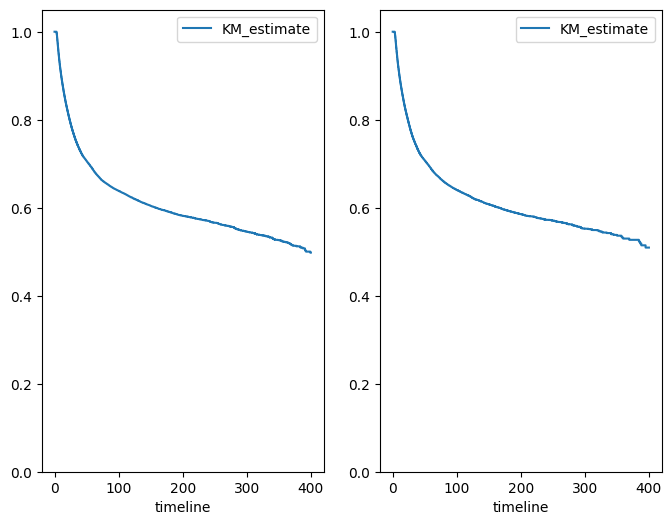

In [5]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df_train["tempo"], df_train["delta"])
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_test["tempo"], df_test["delta"])
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)

plt.show()

In [6]:
y_train = df_train["tempo"].to_numpy() / 12
delta_train = df_train["delta"].to_numpy()
data_train = [y_train, delta_train]
X_train = df_train.iloc[:, 2:]

y_test = df_test["tempo"].to_numpy() / 12
delta_test = df_test["delta"].to_numpy()
data_test = [y_test, delta_test]
X_test = df_test.iloc[:, 2:]

# Birnbaum-Saunders Model

### Without covariates

In [7]:
def build_bs_model():

    def softplus_inv(u):
        return tf.math.log(tf.math.exp(u) - 1)
        
    # parameters = {
    #     # Birnbaum-Sanders component
    #     "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
    #     "beta": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
    # }

    parameters = {
        # Birnbaum-Sanders component
        "alpha": {"link": tf.math.softplus, "link_inv": softplus_inv, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
        "beta": {"link": tf.math.softplus, "link_inv": softplus_inv, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
    }

    def loglikelihood_loss(model, nn_output, data):
        X, y, delta = data
        eps = 1e-7
        y_safe = y + eps

        alpha = model.get_variable("alpha")
        beta = model.get_variable("beta")
        
        log_y = tf.math.log(y_safe)

        sqrt_y_beta = tf.math.sqrt(y_safe / beta)
        sqrt_beta_y = tf.math.sqrt(beta / y_safe)
        z = (1.0 / alpha) * (sqrt_y_beta - sqrt_beta_y)
        
        # Log-density and log-survival for the lognormal component
        S = 0.5 * tf.math.erfc(z / tf.math.sqrt(2.0))
        log_S = tf.math.log(S + eps)      

        pi = tf.cast(np.pi, dtype = tf.float32)
        term1 = tf.math.log(sqrt_y_beta + sqrt_beta_y + eps)
        term2 = -tf.math.log(2.0 * alpha * y_safe * tf.math.sqrt(2.0 * pi))
        term3 = -0.5 * (z ** 2.0)
        log_f = term1 + term2 + term3
        
        # Custom Mixture Log-Likelihood
        loglik_terms = delta * log_f + (1-delta) * log_S
        
        neg_loglik = -tf.reduce_sum(loglik_terms)
        return neg_loglik
    return parameters, loglikelihood_loss, None, None, None

In [8]:
with tf.device("/GPU:0"):
    bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast = \
    build_bs_model()
    seed = 10
    bs_model = thf.ModelNN(bs_parameters, bs_loss,
                           bs_neural_network, bs_call,
                           bs_call_nolast, input_dim = (1,), seed = seed)
    bs_model.train_model(epochs = 5000, x = None, data = data_train,
                         shuffle = True,
                         get_covariances = True,
                         validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                         force_training_validation = False,
                         optimizer_independent = optimizers.Adam(learning_rate = 0.01, clipnorm = 1.0),
                         optimizer_nn = optimizers.Adam(learning_rate = 0.01, clipnorm = 1.0),
                         fine_tune_nn_lr = 0.001, fine_tune_independent_lr = 0.001,
                         early_stopping = True, early_stopping_patience = 30,
                         early_stopping_warmup = 10,
                         reduce_lr = True, reduce_lr_warmup = 0,
                         reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-2, reduce_lr_patience = 25,
                         reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                         deterministic = True,
                         verbose = True, print_freq = 1)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 4115 / 5000 ]  | Loss:  47347.6914 | Best Loss:  47347.6641 | Speed:  56  epoch/s    | Elapsed Time:  73.1530914  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 76.627 seconds.


I0000 00:00:1780517101.013957 1441417 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x60918ae89080


In [9]:
alpha = bs_model.predict("alpha")
beta = bs_model.predict("beta")
print("alpha:", alpha)
print("beta:", beta)

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

sqrt_ts_beta = tf.math.sqrt(ts_grid / beta)
sqrt_beta_ts = tf.math.sqrt(beta / ts_grid)
z_ts = (1.0 / alpha) * (sqrt_ts_beta - sqrt_beta_ts)

S_ts_train = (0.5 * tf.math.erfc(z_ts / tf.math.sqrt(2.0))).numpy()
S_ts_test = (0.5 * tf.math.erfc(z_ts / tf.math.sqrt(2.0))).numpy()


sqrt_y_train_beta = tf.math.sqrt(y_train / beta)
sqrt_beta_y_train = tf.math.sqrt(beta / y_train)
z_y_train = (1.0 / alpha) * (sqrt_y_train_beta - sqrt_beta_y_train)
S_train = (0.5 * tf.math.erfc(z_y_train / tf.math.sqrt(2.0))).numpy()

sqrt_y_test_beta = tf.math.sqrt(y_test / beta)
sqrt_beta_y_test = tf.math.sqrt(beta / y_test)
z_y_test = (1.0 / alpha) * (sqrt_y_test_beta - sqrt_beta_y_test)
S_test = (0.5 * tf.math.erfc(z_y_test / tf.math.sqrt(2.0))).numpy()

H_train = -np.log(S_train)
H_test = -np.log(S_test)

alpha: [5.070562]
beta: [41.322376]


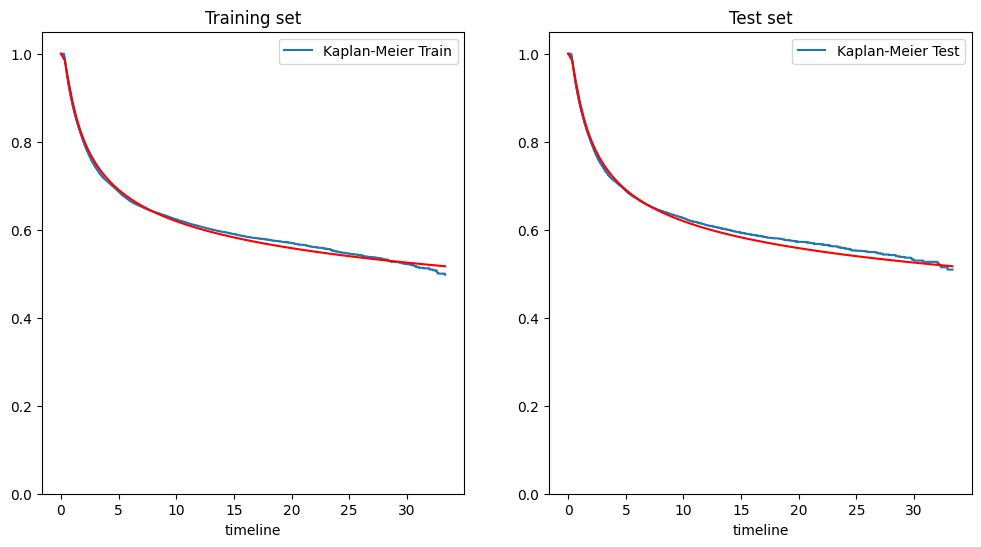

In [10]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
utils.average_kaplan_meier(ts_grid,
                           S_ts_train, S_ts_test,
                           y_train, delta_train, y_test, delta_test, show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()

### With all covariates

In [11]:
def build_bs_model_full( ):    

    def softplus_inv(u):
        return tf.math.log(tf.math.exp(u) - 1)
    
    # parameters = {
    #     # Birnbaum-Sanders component
    #     # "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": bs_model.predict("alpha"), "warmup_time": 0},
    #     "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": bs_model.predict("alpha"), "warmup_time": 0},
    #     "beta": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": bs_model.predict("beta"), "warmup_time": 0},
    # }

    parameters = {
        # Birnbaum-Sanders component
        # "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": bs_model.predict("alpha"), "warmup_time": 0},
        "alpha": {"link": tf.math.softplus, "link_inv": softplus_inv, "par_type": "nn", "shape": 1, "init": bs_model.predict("alpha"), "warmup_time": 0},
        "beta": {"link": tf.math.softplus, "link_inv": softplus_inv, "par_type": "nn", "shape": 1, "init": bs_model.predict("beta"), "warmup_time": 0},
    }

    def loglikelihood_loss(model, nn_output, data):
        X, y, delta = data
        eps = 1e-7
        y_safe = y + eps

        # alpha = model.get_variable("alpha")
        alpha = model.get_variable("alpha", nn_output)
        beta = model.get_variable("beta", nn_output)
        
        log_y = tf.math.log(y_safe)

        sqrt_y_beta = tf.math.sqrt(y_safe / beta)
        sqrt_beta_y = tf.math.sqrt(beta / y_safe)
        z = (1.0 / alpha) * (sqrt_y_beta - sqrt_beta_y)
        
        # Log-density and log-survival for the lognormal component
        S = 0.5 * tf.math.erfc(z / tf.math.sqrt(2.0))
        log_S = tf.math.log(S + eps)

        pi = tf.cast(np.pi, dtype = tf.float32)
        term1 = tf.math.log(sqrt_y_beta + sqrt_beta_y + eps)
        term2 = -tf.math.log(2.0 * alpha * y_safe * tf.math.sqrt(2.0 * pi))
        term3 = -0.5 * (z ** 2.0)
        log_f = term1 + term2 + term3
        
        # Custom Mixture Log-Likelihood
        loglik_terms = delta * log_f + (1-delta) * log_S
        
        neg_loglik = -tf.reduce_sum(loglik_terms)
        return neg_loglik

    def neural_network(model, seed = None):
        initializer = tf.keras.initializers.GlorotNormal(seed=seed)

        elastic_net = tf.keras.regularizers.L1L2(l1 = 0.05, l2 = 0.05)

        model.dense1 = layers.Dense(
            units = 128, 
            activation = "gelu",
            kernel_initializer = initializer,
            kernel_regularizer = elastic_net,
            name = "tabular_features_extractor"
        )
        model.dense2 = layers.Dense(
            units = 64,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_1"
        )
        model.dense3 = layers.Dense(
            units = 32,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.dense4 = layers.Dense(
            units = 8,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.output_layer = layers.Dense(
            units = 2,
            activation = None, # Linear, o exponente fica na Loss function
            kernel_initializer = initializer,
            name = "log_lambda_output"
        )
    
    def neural_network_call(model, x_input, training = False):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.output_layer(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        return x

    return parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

In [12]:
y_train = df_train["tempo"].to_numpy() / 12
delta_train = df_train["delta"].to_numpy()
data_train = [y_train, delta_train]
X_train = df_train.iloc[:, 2:]

y_test = df_test["tempo"].to_numpy() / 12
delta_test = df_test["delta"].to_numpy()
data_test = [y_test, delta_test]
X_test = df_test.iloc[:, 2:]

In [13]:
with tf.device("/GPU:0"):
    bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast = \
    build_bs_model_full( )
    seed = 10
    bs_model_full = thf.ModelNN(bs_parameters, bs_loss,
                                bs_neural_network, bs_call,
                                bs_call_nolast, input_dim = (X_train.shape[1],), seed = seed)
    bs_model_full.pre_train_model(epochs = None, x = X_train, data = data_train, shuffle = True)
    bs_model_full.train_model(epochs = 2500, x = X_train, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                              force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                              optimizer_nn = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                              fine_tune_nn_lr = 0.001, fine_tune_independent_lr = 0.001,
                              early_stopping = True, early_stopping_patience = 30, 
                              early_stopping_warmup = 10,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 5, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 100,
                              finetune_early_stopping_warmup = 10,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1,
                              train_batch_size = None, val_batch_size = None,
                              buffer_size = None, gradient_accumulation_steps = None)

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'model_nn_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 190 / 2500 ]  | Loss:  44805.7305 | Best Loss:  44726.2812 | Speed:  20  epoch/s    | Elapsed Time:  9.32534313  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 2499 / 2500 ]  | Loss:  176522.625 | Best Loss:  176522.625 | Speed:  40  epoch/s    | Elapsed Time:  62.088131  s    
Done.
Extracting covariance structure.
Done.
Optimization finished in 75.720 seconds.


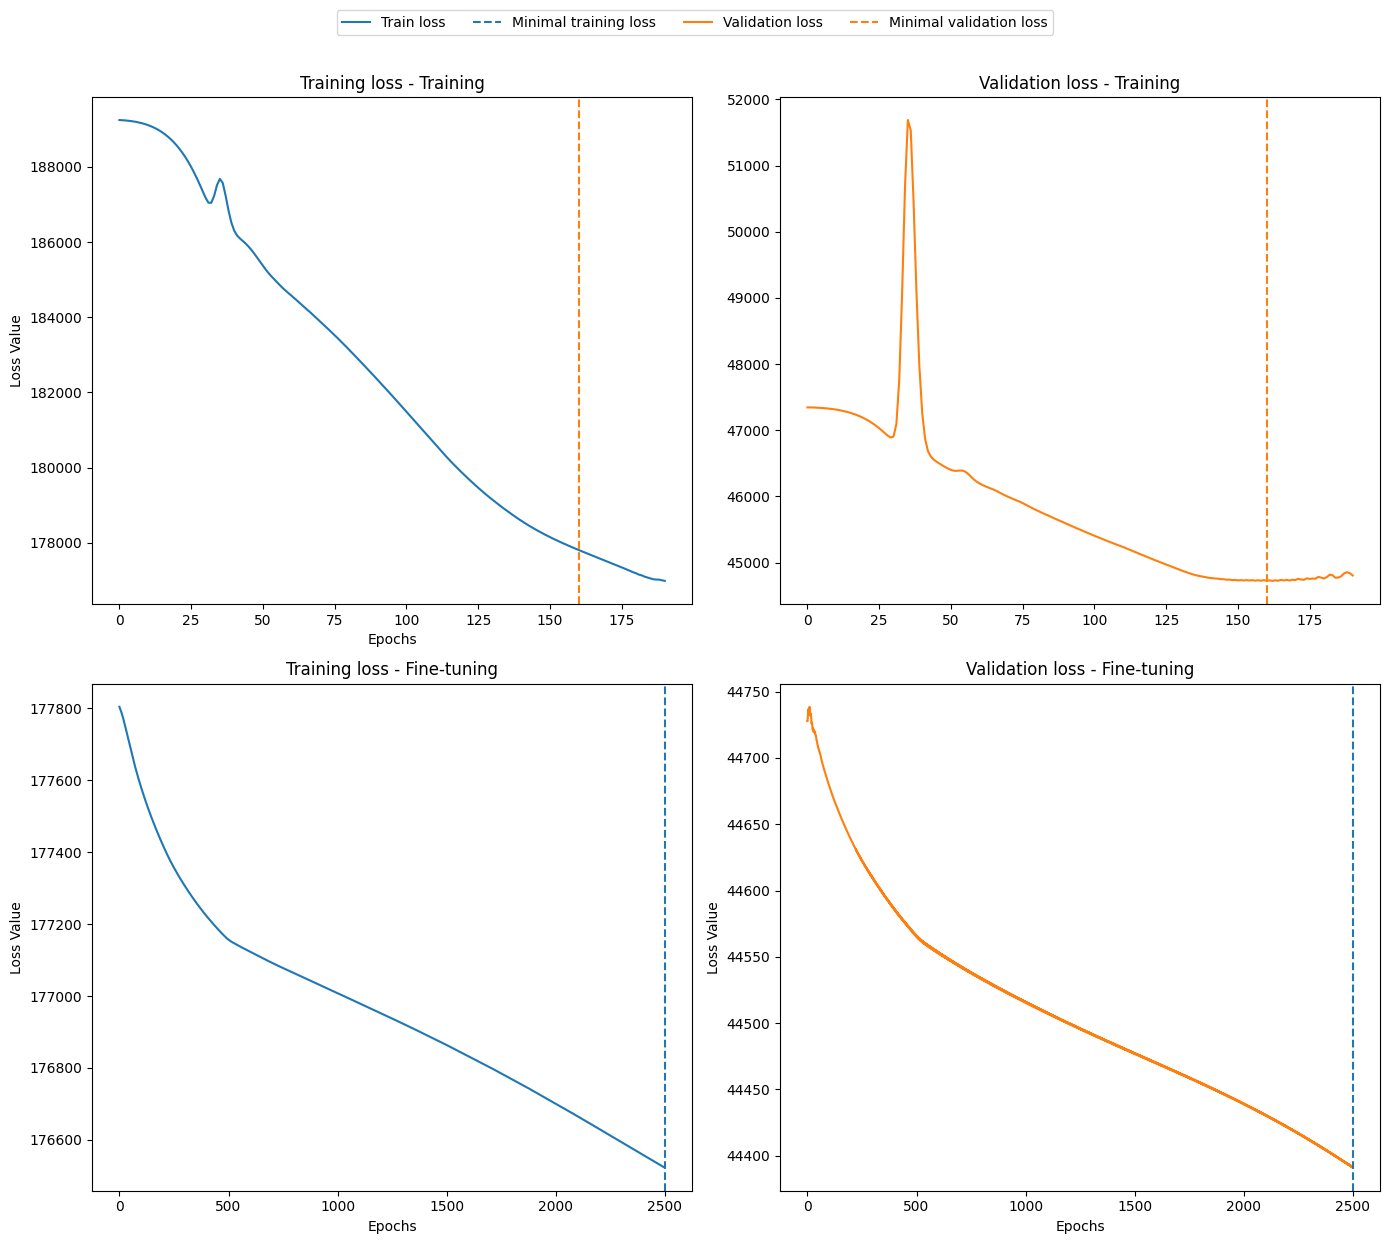

In [14]:
utils.plot_model_convergence( bs_model_full )

In [15]:
pars_train = bs_model_full.predict(X_train)
pars_test = bs_model_full.predict(X_test)

alpha_train = pars_train["alpha"].numpy().flatten()
alpha_test = pars_test["alpha"].numpy().flatten()
beta_train = pars_train["beta"].numpy().flatten()
beta_test = pars_test["beta"].numpy().flatten()

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

sqrt_ts_beta_train_full = tf.math.sqrt(ts_grid / beta_train)
sqrt_beta_ts_train_full = tf.math.sqrt(beta_train / ts_grid)
z_ts_train_full = (1.0 / alpha_train) * (sqrt_ts_beta_train_full - sqrt_beta_ts_train_full)
S_ts_train_full = (0.5 * tf.math.erfc(z_ts_train_full / tf.math.sqrt(2.0))).numpy()

sqrt_ts_beta_test_full = tf.math.sqrt(ts_grid / beta_test)
sqrt_beta_ts_test_full = tf.math.sqrt(beta_test / ts_grid)
z_ts_test_full = (1.0 / alpha_test) * (sqrt_ts_beta_test_full - sqrt_beta_ts_test_full)
S_ts_test_full = (0.5 * tf.math.erfc(z_ts_test_full / tf.math.sqrt(2.0))).numpy()

sqrt_y_beta_train_full = np.sqrt(y_train / beta_train)
sqrt_beta_y_train_full = np.sqrt(beta_train / y_train)
z_y_train_full = (1.0 / alpha_train) * (sqrt_y_beta_train_full - sqrt_beta_y_train_full)
S_train_full = (0.5 * tf.math.erfc(z_y_train_full / tf.math.sqrt(2.0))).numpy()

sqrt_y_beta_test_full = np.sqrt(y_test / beta_test)
sqrt_beta_y_test_full = np.sqrt(beta_test / y_test)
z_y_test_full = (1.0 / alpha_test) * (sqrt_y_beta_test_full - sqrt_beta_y_test_full)
S_test_full = (0.5 * tf.math.erfc(z_y_test_full / tf.math.sqrt(2.0))).numpy()

H_train_full = -np.log( S_train_full )
H_test_full = -np.log( S_test_full )

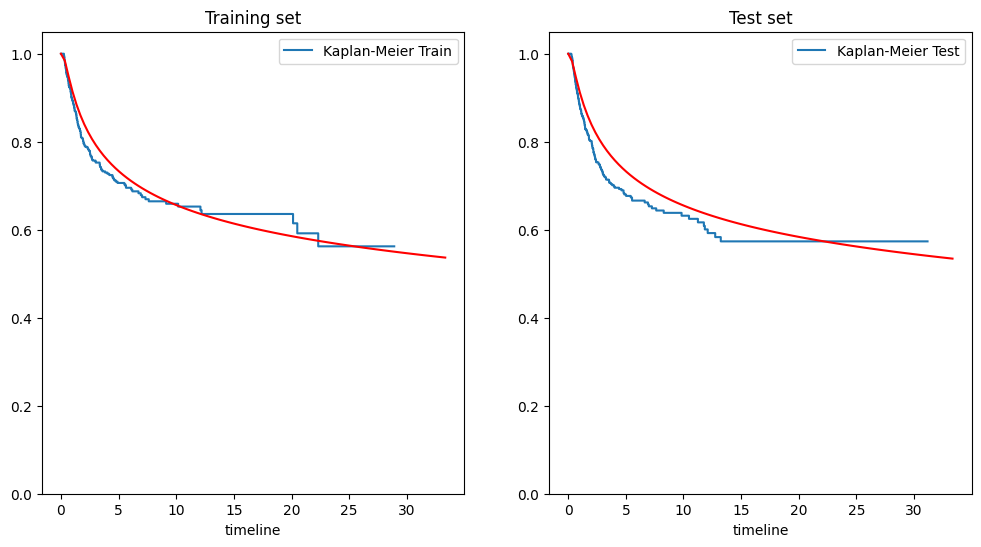

In [31]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

n_max = 1000
# n_max = S_ts_train_full.shape[1]
train_idx = np.random.choice( np.arange(S_ts_train_full.shape[1]), size = n_max )
test_idx = np.random.choice( np.arange(S_ts_test_full.shape[1]), size = n_max )

utils.average_kaplan_meier(ts_grid,
                           S_ts_train_full[:, train_idx], S_ts_test_full[:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

### With mixed covariates

In [17]:
linear_columns = [0, 4, 5, 6, 7, 8, 9]
neuralnet_columns = [i for i in np.arange(X_train.shape[1]) if i not in linear_columns]

z_train = X_train.iloc[:, linear_columns]
X_train_nn = X_train.iloc[:, neuralnet_columns]

z_test = X_test.iloc[:, linear_columns]
X_test_nn = X_test.iloc[:, neuralnet_columns]

data_train = [z_train, y_train, delta_train]
data_test = [z_test, y_test, delta_test]

display( z_train.head(3) )
display( X_train_nn.head(3) )

,idade,sexo_feminino,raca_amarela,raca_branca,raca_indigena,raca_nao identificado,raca_preta
0,0.635547,0,0,0,0,1,0
1,1.947050,1,0,0,0,0,0
2,-1.200556,0,0,0,0,0,0


,horas_semanais,remuneracao_media_nominal,qtd_dias_afastamento,escolaridade_5 ano completo,escolaridade_6 a 9 ano incompleto,escolaridade_analfabeto,escolaridade_ate 5 ano incompleto,escolaridade_doutorado,escolaridade_fundamental completo,escolaridade_medio incompleto,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,0.39808,-0.416631,-0.158797,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
1,0.39808,-0.389206,-0.158797,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0.39808,-0.013666,0.067544,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
def build_bs_model_linear_effects( ):    

    def softplus_inv(u):
        return tf.math.log(tf.math.exp(u) - 1)

    parameters = {
        # Birnbaum-Sanders component
        # "alpha": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": bs_model.predict("alpha"), "warmup_time": 0},
        "alpha": {"link": tf.math.softplus, "link_inv": softplus_inv, "par_type": "nn", "shape": 1, "init": bs_model.predict("alpha"), "warmup_time": 0},
        "beta_beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": z_train.shape[1], "init": 0.0, "warmup_time": 0},
        "beta_nn": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": bs_model.predict("beta"), "warmup_time": 0},
    }

    def loglikelihood_loss(model, nn_output, data):
        X, z_beta, y, delta = data
        eps = 1e-7
        y_safe = y + eps

        # alpha = model.get_variable("alpha")
        alpha = model.get_variable("alpha", nn_output)
        
        beta_beta = model.get_variable("beta_beta")[:,None]
        beta_nn = model.get_variable("beta_nn", nn_output)

        # The scale parameter is written in its logit space as the neuralnet plus the linear effects
        beta = tf.math.softplus( tf.matmul(z_beta, beta_beta) + beta_nn )
        
        log_y = tf.math.log(y_safe)

        sqrt_y_beta = tf.math.sqrt(y_safe / beta)
        sqrt_beta_y = tf.math.sqrt(beta / y_safe)
        z = (1.0 / alpha) * (sqrt_y_beta - sqrt_beta_y)
        
        # Log-density and log-survival for the lognormal component
        S = 0.5 * tf.math.erfc(z / tf.math.sqrt(2.0))
        log_S = tf.math.log(S + eps)

        pi = tf.cast(np.pi, dtype = tf.float32)
        term1 = tf.math.log(sqrt_y_beta + sqrt_beta_y + eps)
        term2 = -tf.math.log(2.0 * alpha * y_safe * tf.math.sqrt(2.0 * pi))
        term3 = -0.5 * (z ** 2.0)
        log_f = term1 + term2 + term3
        
        # Custom Mixture Log-Likelihood
        loglik_terms = delta * log_f + (1-delta) * log_S
        
        neg_loglik = -tf.reduce_sum(loglik_terms)
        return neg_loglik

    def neural_network(model, seed = None):
        initializer = tf.keras.initializers.GlorotNormal(seed=seed)

        elastic_net = tf.keras.regularizers.L1L2(l1 = 0.05, l2 = 0.05)

        model.dense1 = layers.Dense(
            units = 128, 
            activation = "gelu",
            kernel_initializer = initializer,
            kernel_regularizer = elastic_net,
            name = "tabular_features_extractor"
        )
        model.dense2 = layers.Dense(
            units = 64,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_1"
        )
        model.dense3 = layers.Dense(
            units = 32,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.dense4 = layers.Dense(
            units = 8,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.output_layer = layers.Dense(
            units = 2,
            activation = None, # Linear, o exponente fica na Loss function
            kernel_initializer = initializer,
            name = "log_lambda_output"
        )
    
    def neural_network_call(model, x_input, training = False):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.output_layer(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        return x

    return parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

In [19]:
with tf.device("/GPU:0"):
    bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast = \
    build_bs_model_linear_effects( )
    seed = 10
    bs_model_linear = thf.ModelNN(bs_parameters, bs_loss,
                                  bs_neural_network, bs_call,
                                  bs_call_nolast, input_dim = (X_train.shape[1],), seed = seed)
    bs_model_linear.pre_train_model(epochs = None, x = X_train, data = data_train, shuffle = True)
    bs_model_linear.train_model(epochs = 2500, x = X_train, data = data_train,
                                shuffle = True,
                                get_covariances = True,
                                validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                force_training_validation = False,
                                optimizer_independent = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                                optimizer_nn = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                                fine_tune_nn_lr = 0.001, fine_tune_independent_lr = 0.001,
                                early_stopping = True, early_stopping_patience = 30, 
                                early_stopping_warmup = 10,
                                reduce_lr = True, reduce_lr_warmup = 0,
                                reduce_lr_factor = 0.5, reduce_lr_min_delta = 5, reduce_lr_patience = 25,
                                reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                fine_tune = True,
                                finetune_early_stopping = True, finetune_early_stopping_patience = 100,
                                finetune_early_stopping_warmup = 10,
                                finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1e-2, finetune_reduce_lr_patience = 25,
                                finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                deterministic = True,
                                verbose = True, print_freq = 1,
                                train_batch_size = None, val_batch_size = None,
                                buffer_size = None, gradient_accumulation_steps = None)

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'model_nn_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 189 / 2500 ]  | Loss:  44792.2031 | Best Loss:  44724.6797 | Speed:  24  epoch/s    | Elapsed Time:  7.74817944  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 2499 / 2500 ]  | Loss:  176399.75 | Best Loss:  176399.75 | Speed:  39  epoch/s    | Elapsed Time:  63.8597145  s     
Done.
Extracting covariance structure.
Done.
Optimization finished in 75.675 seconds.


In [20]:
pars_train = bs_model_linear.predict(X_train)
pars_test = bs_model_linear.predict(X_test)

alpha_train = pars_train["alpha"].numpy().flatten()
alpha_test = pars_test["alpha"].numpy().flatten()

beta_beta_train = bs_model_linear.predict( "beta_beta" )[:,None]
beta_beta_test = bs_model_linear.predict( "beta_beta" )[:,None]
beta_nn_train = pars_train["beta_nn"].numpy().flatten()
beta_nn_test = pars_test["beta_nn"].numpy().flatten()
beta_train = tf.math.softplus( beta_nn_train + np.dot(z_train, beta_beta_train).flatten() ).numpy()
beta_test = tf.math.softplus( beta_nn_test + np.dot(z_test, beta_beta_test).flatten() ).numpy()

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]

sqrt_ts_beta_train_linear = tf.math.sqrt(ts_grid / beta_train)
sqrt_beta_ts_train_linear = tf.math.sqrt(beta_train / ts_grid)
z_ts_train_linear = (1.0 / alpha_train) * (sqrt_ts_beta_train_linear - sqrt_beta_ts_train_linear)
S_ts_train_linear = (0.5 * tf.math.erfc(z_ts_train_linear / tf.math.sqrt(2.0))).numpy()

sqrt_ts_beta_test_linear = tf.math.sqrt(ts_grid / beta_test)
sqrt_beta_ts_test_linear = tf.math.sqrt(beta_test / ts_grid)
z_ts_test_linear = (1.0 / alpha_test) * (sqrt_ts_beta_test_linear - sqrt_beta_ts_test_linear)
S_ts_test_linear = (0.5 * tf.math.erfc(z_ts_test_linear / tf.math.sqrt(2.0))).numpy()

sqrt_y_beta_train_linear = np.sqrt(y_train / beta_train)
sqrt_beta_y_train_linear = np.sqrt(beta_train / y_train)
z_y_train_linear = (1.0 / alpha_train) * (sqrt_y_beta_train_linear - sqrt_beta_y_train_linear)
S_train_linear = (0.5 * tf.math.erfc(z_y_train_linear / tf.math.sqrt(2.0))).numpy()

sqrt_y_beta_test_linear = np.sqrt(y_test / beta_test)
sqrt_beta_y_test_linear = np.sqrt(beta_test / y_test)
z_y_test_linear = (1.0 / alpha_test) * (sqrt_y_beta_test_linear - sqrt_beta_y_test_linear)
S_test_linear = (0.5 * tf.math.erfc(z_y_test_linear / tf.math.sqrt(2.0))).numpy()

H_train_linear = -np.log( S_train_linear )
H_test_linear = -np.log( S_test_linear )

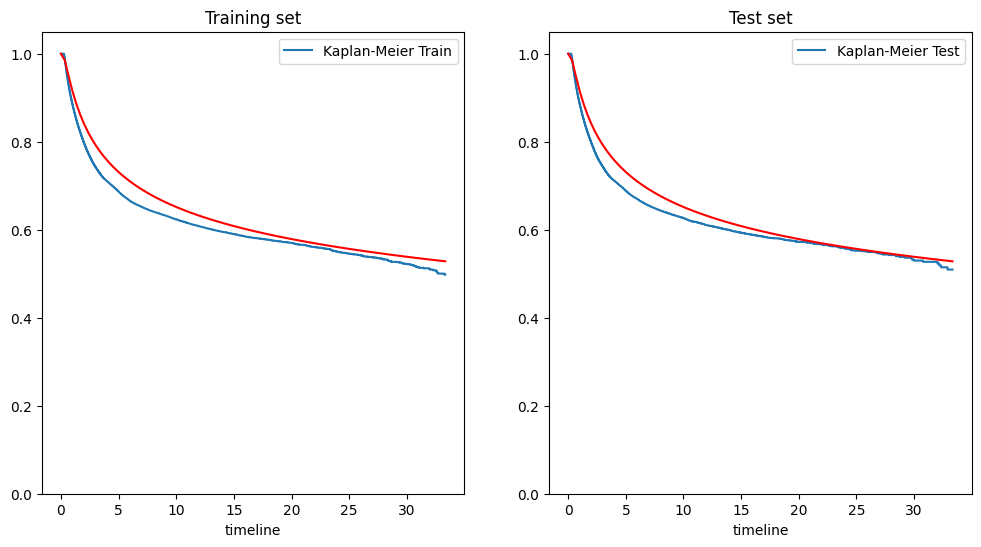

In [21]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
 
n_max = 5000
n_max = S_ts_train_linear.shape[1]
train_idx = np.random.choice( np.arange(S_ts_train_linear.shape[1]), size = np.min([n_max, S_ts_train_linear.shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(S_ts_test_linear.shape[1]), size = np.min([n_max, S_ts_test_linear.shape[1]]), replace = False )

utils.average_kaplan_meier(ts_grid,
                           S_ts_train_linear[:, train_idx], S_ts_test_linear[:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [22]:
beta_summary = bs_model_linear.summary()
beta_summary

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2714: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta_beta'].
  warnings.warn(


,index,beta_beta[0],beta_beta[0]_se,beta_beta[0]_lower,beta_beta[0]_upper,beta_beta[1],beta_beta[1]_se,beta_beta[1]_lower,beta_beta[1]_upper,beta_beta[2],...,beta_beta[4]_lower,beta_beta[4]_upper,beta_beta[5],beta_beta[5]_se,beta_beta[5]_lower,beta_beta[5]_upper,beta_beta[6],beta_beta[6]_se,beta_beta[6]_lower,beta_beta[6]_upper
0,1,2.664695,0.357449,1.964108,3.365283,-2.286968,0.391545,-3.054382,-1.519555,-0.053123,...,-3.186444,5.427645,2.200524,1.109931,0.025099,4.375949,-2.710827,0.458639,-3.609742,-1.811911


In [23]:
beta_summary = bs_model_linear.summary()

beta_hats = []
beta_ses = []
beta_statistics = []
beta_pvalues = []
beta_CIs = []
for j, beta in enumerate(beta_summary.columns[1::4]):
    beta_hat = float( beta_summary.iloc[0,j*4+1] )
    se = float( beta_summary.iloc[0,j*4+2] )

    test_statistic = beta_hat / se
    p_value = 2.0 * (1.0 - norm.cdf(np.abs(test_statistic)))
    
    lower = float( beta_summary.iloc[0,j*4+3] )
    upper = float( beta_summary.iloc[0,j*4+4] )

    beta_hats.append( beta_hat )
    beta_ses.append( se )
    beta_statistics.append( test_statistic )
    beta_pvalues.append( p_value )
    beta_CIs.append("({} ; {})".format(np.round(lower,4), np.round(upper,4)))
beta_summary = pd.DataFrame({"Coef": beta_hats, "Se": beta_ses, "Z": beta_statistics, "pvalue": beta_pvalues, "CI(95%)": beta_CIs})
beta_summary.index = z_train.columns
beta_summary

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2714: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta_beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,2.664695,0.357449,7.454752,8.992806e-14,(1.9641 ; 3.3653)
sexo_feminino,-2.286968,0.391545,-5.840887,5.192352e-09,(-3.0544 ; -1.5196)
raca_amarela,-0.053123,0.886313,-0.059937,9.522059e-01,(-1.7903 ; 1.684)
raca_branca,-0.340349,0.349148,-0.974799,3.296602e-01,(-1.0247 ; 0.344)
raca_indigena,1.120601,2.197512,0.509941,6.100931e-01,(-3.1864 ; 5.4276)
raca_nao identificado,2.200524,1.109931,1.982577,4.741465e-02,(0.0251 ; 4.3759)
raca_preta,-2.710827,0.458639,-5.910592,3.408809e-09,(-3.6097 ; -1.8119)


In [33]:
3.296602e-01

0.3296602

In [34]:
6.100931e-01	

0.6100931

# Model evaluation

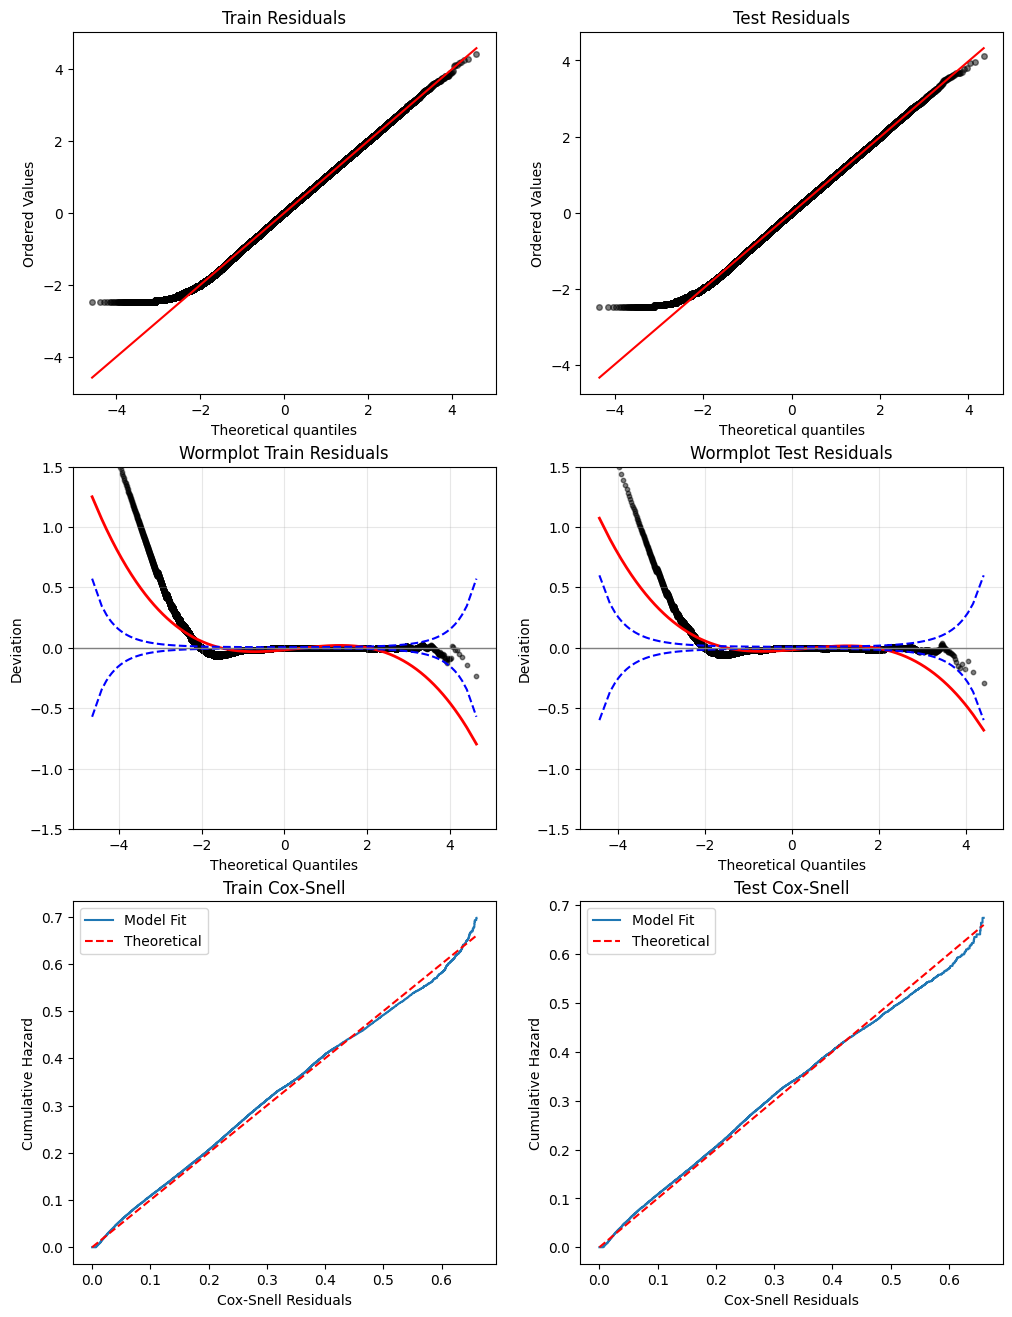

In [24]:
quant_residuals_train = utils.compute_randomized_residuals_censoring(S_train, delta_train)
quant_residuals_test = utils.compute_randomized_residuals_censoring(S_test, delta_test)
cs_residuals_train = H_train
cs_residuals_test = H_test 

fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12,16))

utils.plot_qq(quant_residuals_train, ax = ax[0,0], title = "Train Residuals")
utils.plot_qq(quant_residuals_test, ax = ax[0,1], title = "Test Residuals")
utils.plot_worm(quant_residuals_train, ax = ax[1,0], title = "Wormplot Train Residuals")
utils.plot_worm(quant_residuals_test, ax = ax[1,1], title = "Wormplot Test Residuals")
utils.plot_cox_snell(cs_residuals_train, delta_train, ax = ax[2,0], title = "Train Cox-Snell")
utils.plot_cox_snell(cs_residuals_test, delta_test, ax = ax[2,1], title = "Test Cox-Snell")

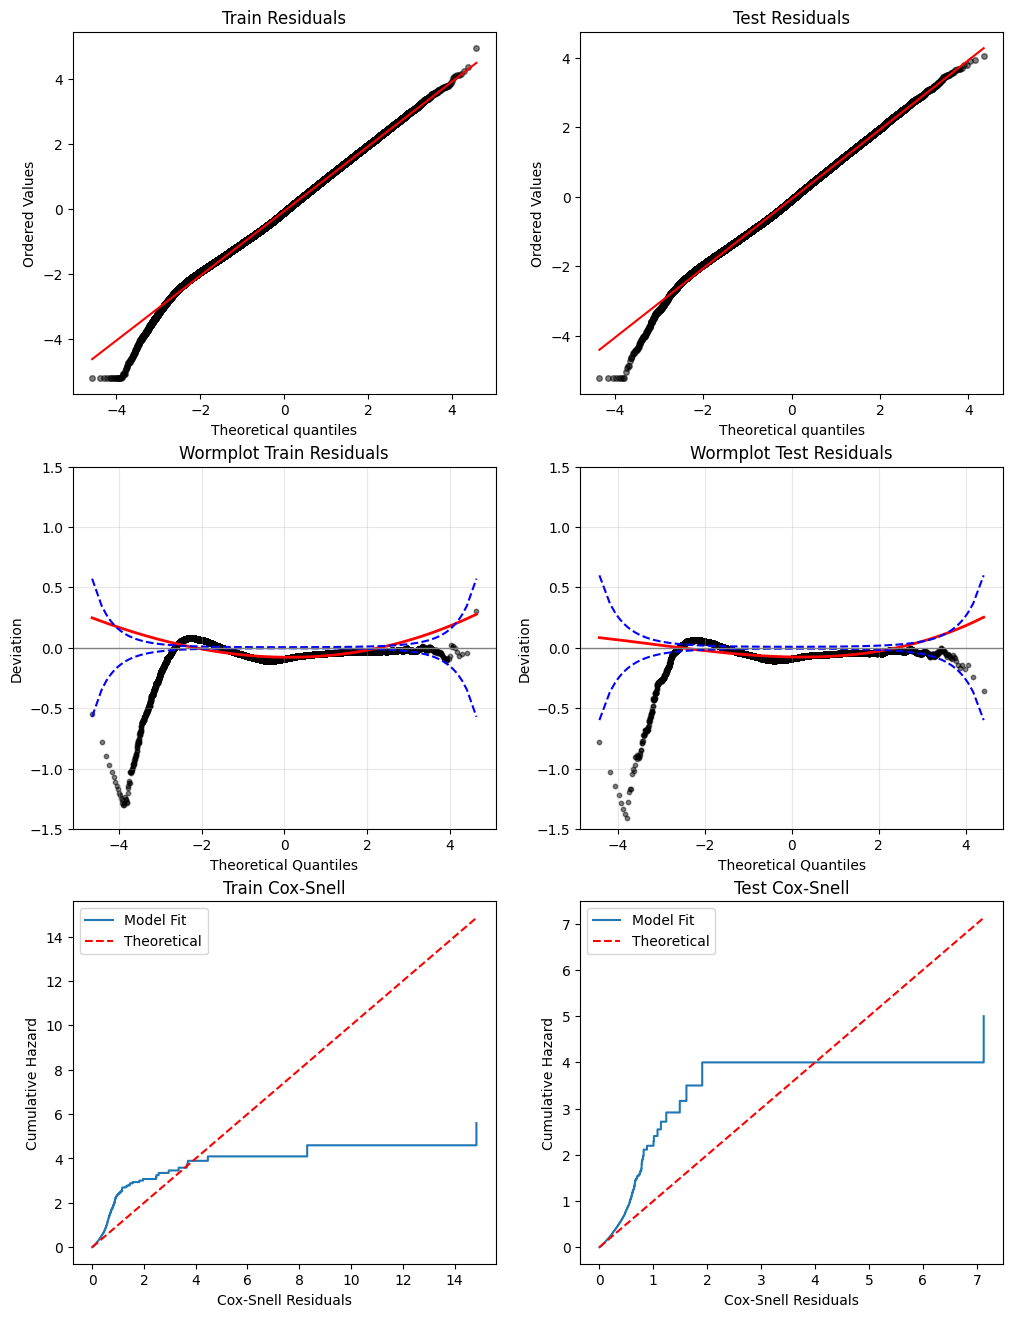

In [25]:
quant_residuals_train_full = utils.compute_randomized_residuals_censoring(S_train_full, delta_train)
quant_residuals_test_full = utils.compute_randomized_residuals_censoring(S_test_full, delta_test)
cs_residuals_train_full = H_train_full
cs_residuals_test_full = H_test_full

fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12,16))

utils.plot_qq(quant_residuals_train_full, ax = ax[0,0], title = "Train Residuals")
utils.plot_qq(quant_residuals_test_full, ax = ax[0,1], title = "Test Residuals")
utils.plot_worm(quant_residuals_train_full, ax = ax[1,0], title = "Wormplot Train Residuals")
utils.plot_worm(quant_residuals_test_full, ax = ax[1,1], title = "Wormplot Test Residuals")
utils.plot_cox_snell(cs_residuals_train_full, delta_train, ax = ax[2,0], title = "Train Cox-Snell")
utils.plot_cox_snell(cs_residuals_test_full, delta_test, ax = ax[2,1], title = "Test Cox-Snell")

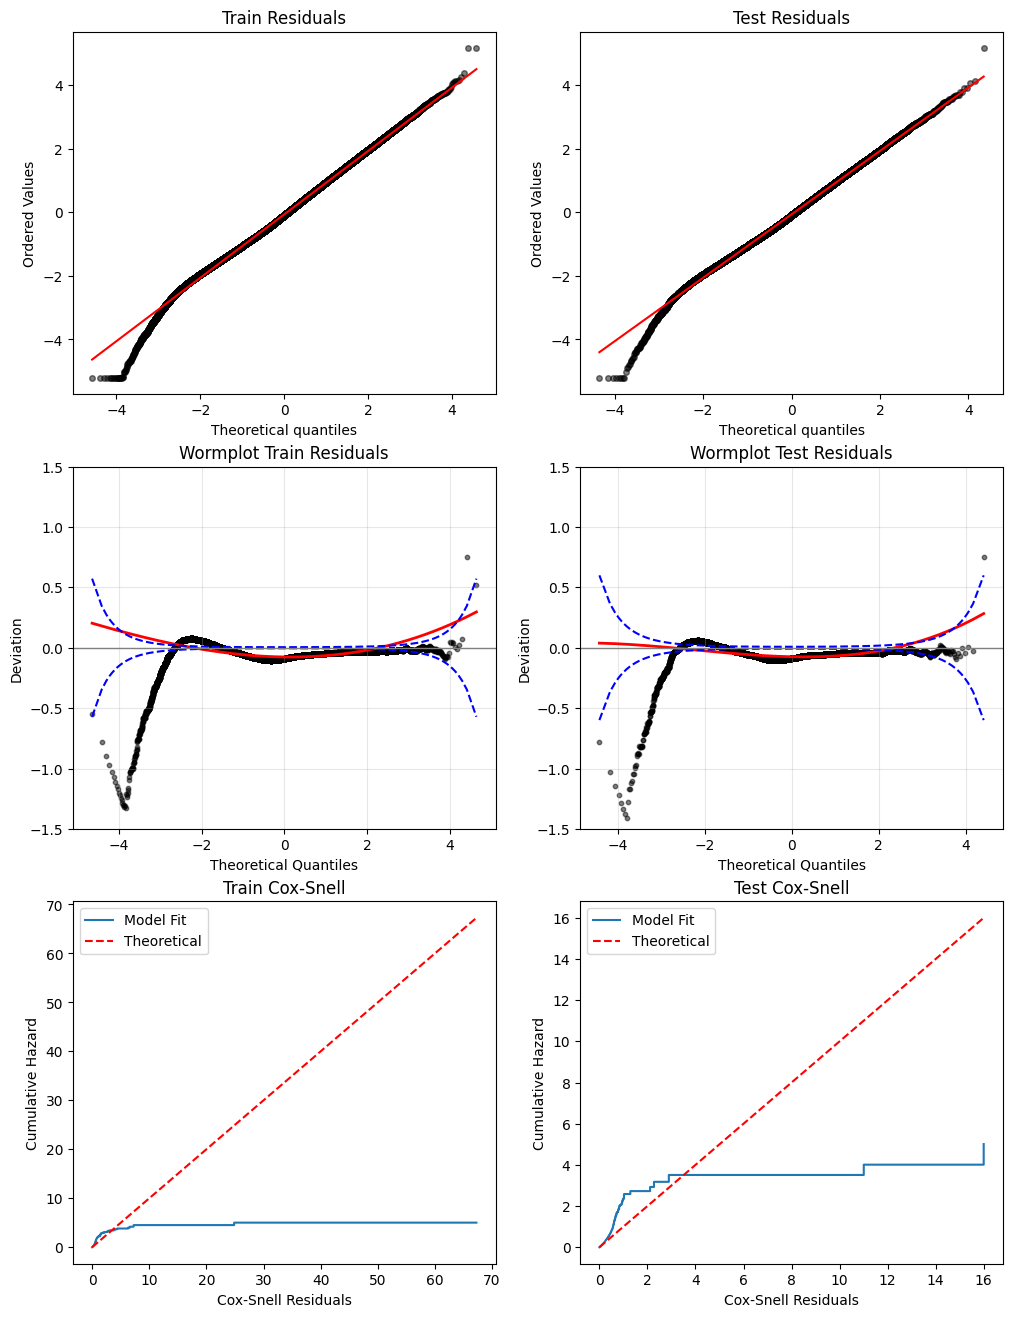

In [26]:
quant_residuals_train_linear = utils.compute_randomized_residuals_censoring(S_train_linear, delta_train)
quant_residuals_test_linear = utils.compute_randomized_residuals_censoring(S_test_linear, delta_test)
cs_residuals_train_linear = H_train_linear
cs_residuals_test_linear = H_test_linear

fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12,16))

utils.plot_qq(quant_residuals_train_linear, ax = ax[0,0], title = "Train Residuals")
utils.plot_qq(quant_residuals_test_linear, ax = ax[0,1], title = "Test Residuals")
utils.plot_worm(quant_residuals_train_linear, ax = ax[1,0], title = "Wormplot Train Residuals")
utils.plot_worm(quant_residuals_test_linear, ax = ax[1,1], title = "Wormplot Test Residuals")
utils.plot_cox_snell(cs_residuals_train_linear, delta_train, ax = ax[2,0], title = "Train Cox-Snell")
utils.plot_cox_snell(cs_residuals_test_linear, delta_test, ax = ax[2,1], title = "Test Cox-Snell")

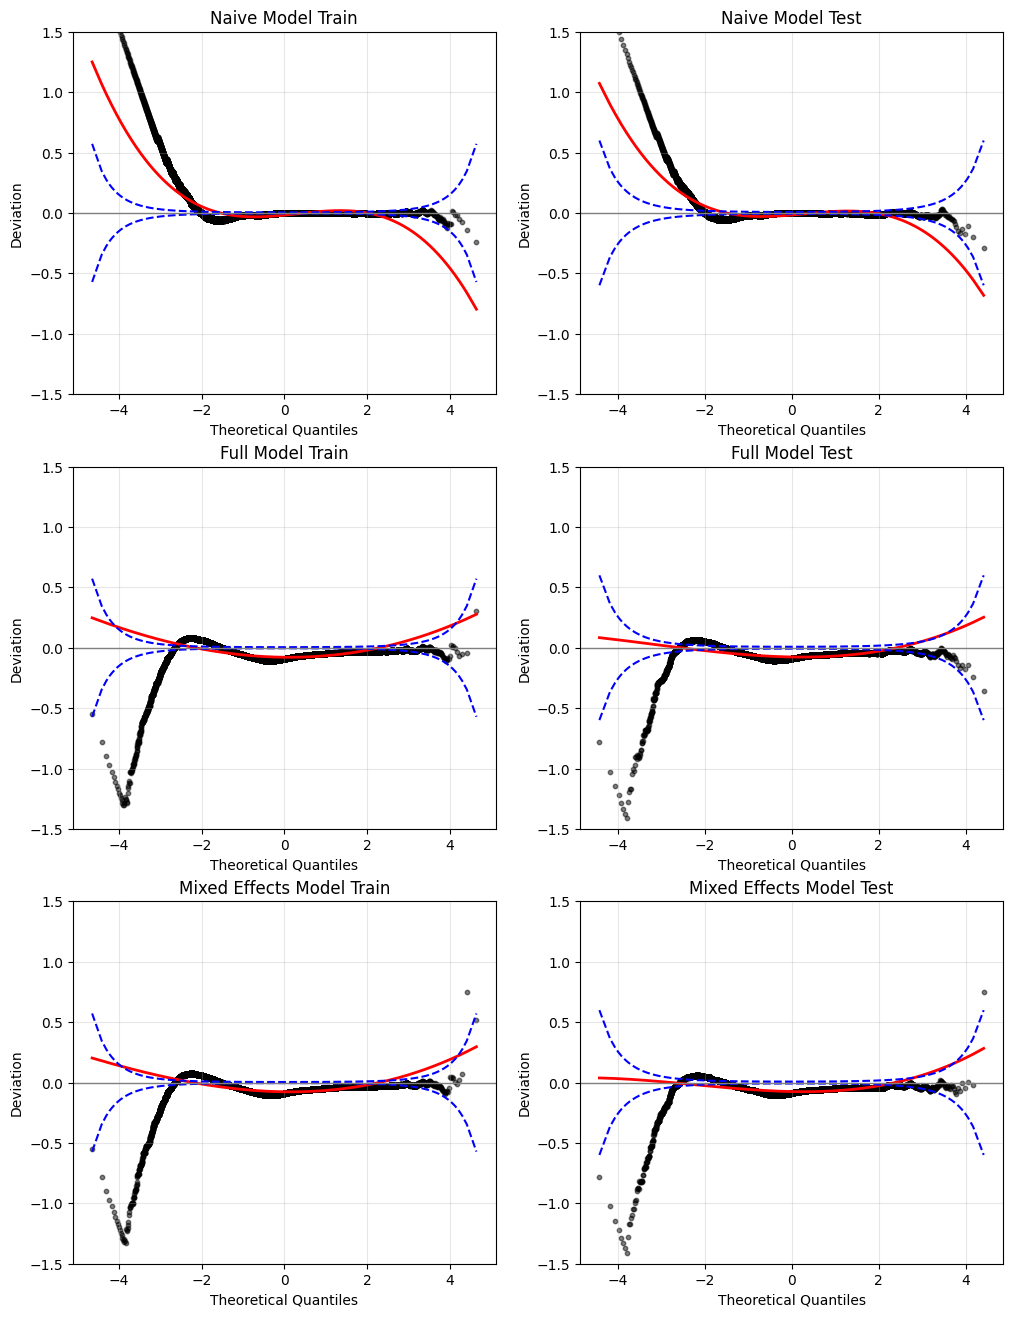

In [27]:
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12,16))

utils.plot_worm(quant_residuals_train, ax = ax[0,0], title = "Naive Model Train")
utils.plot_worm(quant_residuals_test, ax = ax[0,1], title = "Naive Model Test")
utils.plot_worm(quant_residuals_train_full, ax = ax[1,0], title = "Full Model Train")
utils.plot_worm(quant_residuals_test_full, ax = ax[1,1], title = "Full Model Test")
utils.plot_worm(quant_residuals_train_linear, ax = ax[2,0], title = "Mixed Effects Model Train")
utils.plot_worm(quant_residuals_test_linear, ax = ax[2,1], title = "Mixed Effects Model Test")